<h1 style='color:Green'>Linear Regression with Multiple Features</h1>  

## Before drive into code, Let's understand about Hypothesis, Loss Function, Training(Gradient Descent) for Multiple features

[View the PDF](./003-Linear-Regration-Multiple-Features.pdf)


In [2]:
from IPython.display import IFrame
IFrame("003-Linear-Regration-Multiple-Features.pdf", width=800, height=600)

In [64]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
plt.style.use('seaborn-v0_8-darkgrid')

In [62]:
#print(plt.style.available)

In [4]:
#Step-1 Generate Data

X,y = make_regression(n_samples=500, n_features=12, n_informative=7, noise=20.5, random_state=0)
print(X.shape, y.shape)
n_features = X.shape[1]

(500, 12) (500,)


In [5]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.116230,-0.410382,-1.279161,0.863520,-0.804754,0.507239,-0.947489,0.528944,2.346647,1.401345,0.246148,0.244443
1,0.140672,0.100159,0.382598,-1.696131,0.730184,-1.216077,-0.743672,-0.475175,-1.857483,0.240057,1.272954,-0.159012
2,0.785681,-0.464928,2.634603,-0.577244,1.197128,-0.493460,-0.554345,-0.124434,-1.637706,-0.942246,1.053172,-1.168830
3,1.231254,-0.221390,-1.155792,-0.308803,0.198673,-0.173350,-1.585853,-0.163399,-0.174292,0.063490,-0.156303,1.031319
4,-1.998639,0.531178,0.146441,0.217180,0.078211,-0.289005,-1.146000,-0.128242,1.404546,0.824557,-0.271772,0.047066


In [6]:
#Step-2 Normalise
def normalise(X): 
    u = X.mean(axis=0)
    std = X.std(axis=0) 
    return (X-u)/std 

In [7]:
X = normalise(X)

In [8]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.063697,-0.417442,-1.305621,0.915629,-0.878724,0.584898,-0.985969,0.619747,2.312495,1.469736,0.254503,0.182003
1,0.186140,0.100468,0.427965,-1.574125,0.761536,-1.217803,-0.776356,-0.426021,-1.855369,0.258690,1.299016,-0.209680
2,0.813412,-0.472775,2.777309,-0.485791,1.260521,-0.461899,-0.581644,-0.060732,-1.637488,-0.974271,1.075445,-1.190033
3,1.246731,-0.225723,-1.176920,-0.224681,0.193555,-0.127043,-1.642489,-0.101313,-0.186698,0.074559,-0.154889,0.945918
4,-1.894342,0.537708,0.181600,0.286939,0.064827,-0.248026,-1.190127,-0.064697,1.378520,0.868235,-0.272349,-0.009615


In [9]:
X.mean(axis=0) #Column wise mean

array([ 3.44169138e-18, -3.07531778e-17, -2.84217094e-17, -3.41948692e-17,
       -7.43849426e-18,  1.18405286e-16, -1.53210777e-17, -1.89293026e-17,
       -1.75415238e-17,  7.77156117e-18, -1.59872116e-17,  4.28546088e-17])

In [10]:
X.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

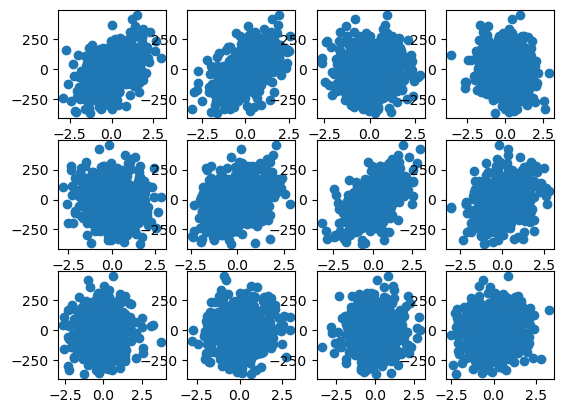

In [11]:
#Step-3 Visualise y as function of each feature 

for f in range(0,12): 
    plt.subplot(3,4,f+1)
    plt.scatter(X[:,f], y) 
plt.show()

In [12]:
#Step-4 Train Test Split 
XT, Xt, yT, yt = train_test_split(X,y,test_size=0.3,shuffle=False, random_state=0)

In [13]:
print(XT.shape, yT.shape, Xt.shape, yt.shape)

(350, 12) (350,) (150, 12) (150,)


In [14]:
#Data preprocessing
def preprocess(X): 
    if X.shape[1] == n_features:
        m = X.shape[0]
        ones = np.ones((m,1))
        X = np.hstack((ones, X))

    return X

In [50]:
#Step-5 Modelling 

def hypothesis(X, theta): 
    return np.dot(X, theta)

def loss(X, y, theta):
    yp = hypothesis(X, theta)
    error = np.mean((y-yp)**2)  #Or, error = np.sum((y-yp)**2) / m  
    return error 

def gradient(X, y, theta):
    yp = hypothesis(X,theta)
    grad = np.dot(X.T, (yp-y))  # X.T --> X transpose
    m = X.shape[0] 
    return grad/m 

def train(X, y, lr=0.1, max_iters=100):
    n = X.shape[1]
    theta = np.random.randn(n)
    error_list = []

    for i in range(max_iters): 
        e = loss(X, y, theta)
        error_list.append(e)
        grad = gradient(X, y, theta)
        theta = theta - lr*grad
        
    plt.plot(error_list)
    return theta
    

In [52]:
pd.DataFrame(XT).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,-0.063697,-0.417442,-1.305621,0.915629,-0.878724,0.584898,-0.985969,0.619747,2.312495,1.469736,0.254503,0.182003
1,1.0,0.186140,0.100468,0.427965,-1.574125,0.761536,-1.217803,-0.776356,-0.426021,-1.855369,0.258690,1.299016,-0.209680
2,1.0,0.813412,-0.472775,2.777309,-0.485791,1.260521,-0.461899,-0.581644,-0.060732,-1.637488,-0.974271,1.075445,-1.190033
3,1.0,1.246731,-0.225723,-1.176920,-0.224681,0.193555,-0.127043,-1.642489,-0.101313,-0.186698,0.074559,-0.154889,0.945918
4,1.0,-1.894342,0.537708,0.181600,0.286939,0.064827,-0.248026,-1.190127,-0.064697,1.378520,0.868235,-0.272349,-0.009615


In [54]:
XT = preprocess(XT)
pd.DataFrame(XT).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,-0.063697,-0.417442,-1.305621,0.915629,-0.878724,0.584898,-0.985969,0.619747,2.312495,1.469736,0.254503,0.182003
1,1.0,0.186140,0.100468,0.427965,-1.574125,0.761536,-1.217803,-0.776356,-0.426021,-1.855369,0.258690,1.299016,-0.209680
2,1.0,0.813412,-0.472775,2.777309,-0.485791,1.260521,-0.461899,-0.581644,-0.060732,-1.637488,-0.974271,1.075445,-1.190033
3,1.0,1.246731,-0.225723,-1.176920,-0.224681,0.193555,-0.127043,-1.642489,-0.101313,-0.186698,0.074559,-0.154889,0.945918
4,1.0,-1.894342,0.537708,0.181600,0.286939,0.064827,-0.248026,-1.190127,-0.064697,1.378520,0.868235,-0.272349,-0.009615


In [56]:
Xt = preprocess(Xt)
pd.DataFrame(Xt).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.451354,-0.565963,-1.501839,0.151794,0.384242,0.922140,-0.612018,-0.093090,0.134843,0.171181,0.666644,-1.347374
1,1.0,-1.278664,-0.173715,-0.543000,-1.216051,0.228599,-1.001318,-0.219670,-0.435431,0.974002,-0.810062,-0.329464,-1.423374
2,1.0,-0.254368,0.955739,0.661356,0.827827,-1.283865,-1.156377,-0.173684,0.847044,-2.650142,-0.726547,-1.205339,2.135566
3,1.0,0.594912,1.291409,-0.931498,0.034251,0.396182,-0.348148,0.788012,-1.664882,1.092440,1.198912,0.441911,-0.040603
4,1.0,-0.147492,0.292040,0.589437,1.116269,1.686125,0.275350,-0.651149,-0.507742,1.183226,0.845169,0.346163,0.103684


[-7.00268418 63.51721021 79.73112188 -1.37597762 -0.11449522 -0.94653688
 39.99196357 83.00815913 40.82210395 -0.33554001  9.96043092 -0.74760428
 10.60846725]


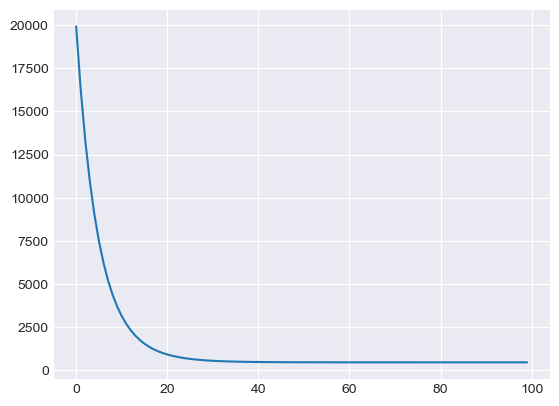

In [66]:
theta = train(XT, yT)
print(theta)

In [68]:
#Model Evaluation 
def r2Score(y, yp): 
    T1 = np.sum((y-yp)**2)
    T2 = np.sum((y-y.mean())**2)
    return 1 - T1/T2 

In [72]:
yp = hypothesis(Xt, theta)

In [75]:
r2Score(yt, yp)

0.9815587139587261

# Linear Regression with Sk-Learn 

In [82]:
from sklearn.linear_model import LinearRegression

In [86]:
model = LinearRegression()

In [88]:
model.fit(XT, yT)

LinearRegression()

In [92]:
yp = model.predict(Xt)

In [94]:
model.score(Xt, yt)

0.9815670840201077